# 03 · Drift, adaptación y decisión

Qué se responde aquí:

1. ¿Compensa olvidar datos antiguos, y con qué tamaño de ventana?
2. ¿Los detectores encuentran el cambio, y con cuánto retraso?
3. ¿Qué límites tiene el resultado?

Siete estrategias sobre los mismos eventos, con la misma semilla, la misma política
y la misma familia de modelos.

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent          # el notebook puede abrirse desde notebooks/
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fraud_adaptive.pipeline import load_configs
from fraud_adaptive.tracking import read_json

CONFIGS = load_configs(ROOT / "configs")
# Corrida de la que provienen las cifras del informe.
RUN_ID = "v3"
RUN_DIR = ROOT / CONFIGS["base"]["paths"]["runs"] / RUN_ID
REPORTS = ROOT / CONFIGS["base"]["paths"]["reports"]

MANIFEST = read_json(ROOT / CONFIGS["base"]["paths"]["manifests"] / "sources.json")
DATA_SOURCE = MANIFEST.get("data_source", "desconocido")

if DATA_SOURCE == "sintetico_sustituto":
    print("Aviso: los datos son un sustituto sintetico y las cifras no describen IEEE-CIS.")
else:
    print("Datos: IEEE-CIS Fraud Detection (particion train).")
print("Run:", RUN_DIR)

Datos: IEEE-CIS Fraud Detection (particion train).
Run: C:\Users\25por\OneDrive\Desktop\utec\planifica\PLANIFICA_PROYECTO01\runs\v3


## 1. El protocolo temporal

En cada actualización, cada versión usa tres roles: predictor, calibrador y validación de promoción. Las dos reservas de 7 días son idénticas para todas las estrategias, de modo que una diferencia de costo se puede atribuir a la ventana.

In [2]:
splits = read_json(ROOT / CONFIGS["base"]["paths"]["manifests"] / "splits.json")

print(f"L = {splits['label_delay_days']} días   cadencia = {splits['cadence_days']} días")
print(f"Regla de elegibilidad: {splits['eligibility_rule']}\n")

filas = []
for estrategia, versiones in splits["versions"].items():
    for v in versiones:
        filas.append({
            "version": v["version_id"], "T": v["update_time"], "c": v["cutoff"],
            "predictor": f"[{v['predictor'][0]},{v['predictor'][1]})",
            "dias_fit": v["predictor_days"],
            "calibracion": f"[{v['calibration'][0]},{v['calibration'][1]})",
            "H": f"[{v['promotion_validation'][0]},{v['promotion_validation'][1]})",
        })
pd.DataFrame(filas)

L = 30 días   cadencia = 15 días
Regla de elegibilidad: available_at < cutoff (estricto)



,version,T,c,predictor,dias_fit,calibracion,H
0,S0_T120,120,90,"[0,69)",69,"[76,83)","[83,90)"
1,E15_T120,120,90,"[0,76)",76,"[76,83)","[83,90)"
2,E15_T135,135,105,"[0,91)",91,"[91,98)","[98,105)"
3,E15_T150,150,120,"[0,106)",106,"[106,113)","[113,120)"
4,E15_T165,165,135,"[0,121)",121,"[121,128)","[128,135)"
5,W30_T120,120,90,"[60,76)",16,"[76,83)","[83,90)"
6,W30_T135,135,105,"[75,91)",16,"[91,98)","[98,105)"
7,W30_T150,150,120,"[90,106)",16,"[106,113)","[113,120)"
8,W30_T165,165,135,"[105,121)",16,"[121,128)","[128,135)"
9,W60_T120,120,90,"[30,76)",46,"[76,83)","[83,90)"


## 2. Resultado central

Una fila por estrategia con métricas técnicas, de decisión y sociales. `S0` es el modelo estático de referencia y `E15`, que reentrena con todo el histórico, es la estrategia recomendada. F1 y balanced accuracy se evalúan en el umbral de FPR 1 % fijado en validación.

In [3]:
adaptacion = pd.read_csv(REPORTS / "tables" / "adaptacion.csv")
adaptacion[["estrategia", "ap", "skill", "brier", "f1", "balanced_accuracy", "costo_um_tx",
            "costo_ic_low", "costo_ic_high", "bloqueo_legitimas",
            "n_revisiones", "versiones_activadas"]].round(4)

,estrategia,ap,skill,brier,f1,balanced_accuracy,costo_um_tx,costo_ic_low,costo_ic_high,bloqueo_legitimas,n_revisiones,versiones_activadas
0,S0,0.4828,0.4643,0.0233,0.4802,0.6947,2.0921,1.9106,2.2556,0.0087,8648,1
1,E15,0.4965,0.4785,0.0231,0.4882,0.7064,1.9840,1.8208,2.1549,0.0126,8722,4
2,W30,0.4701,0.4512,0.0238,0.4715,0.6948,2.1830,1.9426,2.4214,0.0127,8744,4
3,W60,0.4802,0.4616,0.0237,0.4802,0.7045,2.1087,1.9173,2.3299,0.0138,8745,4
4,W90,0.4901,0.4719,0.0234,0.4806,0.7037,2.0573,1.9086,2.2083,0.0136,8772,4
5,R46_medio,0.4571,0.4377,0.0242,0.4613,0.6916,2.2146,2.0329,2.3818,0.0140,8925,4
6,R46_antiguo,0.4681,0.4491,0.0236,0.4722,0.6845,2.1171,1.9428,2.2456,0.0098,8844,1


### AP por bloque

Si olvidar compensara, las ventanas cortas sostendrían el AP en los bloques donde el estático cae.

In [4]:
adaptacion[["estrategia", "ap_B1", "ap_B2", "ap_B3", "ap_B4"]].round(4)

,estrategia,ap_B1,ap_B2,ap_B3,ap_B4
0,S0,0.5257,0.3907,0.4769,0.5144
1,E15,0.5287,0.4172,0.4880,0.5389
2,W30,0.4877,0.3882,0.4756,0.5177
3,W60,0.5071,0.3905,0.5005,0.5303
4,W90,0.5287,0.4145,0.4920,0.5218
5,R46_medio,0.4944,0.3597,0.4659,0.5006
6,R46_antiguo,0.5077,0.3780,0.4498,0.5103


### Diferencia pareada frente a las referencias

Remuestreo de bloques contiguos de 7 días sobre los mismos eventos. Un intervalo que no cruza el cero indica una diferencia consistente.

In [5]:
cols = [c for c in adaptacion.columns if c.startswith("delta_costo_vs_")]
adaptacion[["estrategia"] + cols].round(4)

,estrategia,delta_costo_vs_S0,delta_costo_vs_S0_ic_low,delta_costo_vs_S0_ic_high,delta_costo_vs_E15,delta_costo_vs_E15_ic_low,delta_costo_vs_E15_ic_high
0,S0,0.0000,0.0000,0.0000,0.1081,-0.0019,0.2053
1,E15,-0.1081,-0.2053,0.0019,0.0000,0.0000,0.0000
2,W30,0.0909,-0.0613,0.2803,0.1989,0.1091,0.2850
3,W60,0.0166,-0.1143,0.1654,0.1247,0.0494,0.1897
4,W90,-0.0348,-0.1279,0.0609,0.0733,0.0368,0.1170
5,R46_medio,0.1225,0.0040,0.2289,0.2306,0.1558,0.2975
6,R46_antiguo,0.0250,-0.0590,0.0898,0.1331,0.0256,0.2179


## 3. Objetivos diagnósticos

Los umbrales se fijaron en validación y se aplican sin reajuste. La tabla muestra el FPR y la precisión que obtiene cada estrategia en test.

In [6]:
objetivos = CONFIGS["decision"]["diagnostic_targets"]
tabla = adaptacion[["estrategia", "recall_at_fpr1", "fpr_obtenido",
                    "recall_at_precision80", "precision_obtenida"]].round(4)
tabla["cumple_fpr"] = tabla["fpr_obtenido"] <= objetivos["fpr_target"]
tabla["cumple_precision"] = tabla["precision_obtenida"] >= objetivos["precision_target"]
print(f"Objetivos: FPR <= {objetivos['fpr_target']}, precisión >= {objetivos['precision_target']}\n")
display(tabla)

cumplen = tabla.loc[tabla["cumple_fpr"] & tabla["cumple_precision"], "estrategia"]
print("\nCumplen ambos objetivos:", ", ".join(cumplen) if len(cumplen) else "ninguna")

Objetivos: FPR <= 0.01, precisión >= 0.8



,estrategia,recall_at_fpr1,fpr_obtenido,recall_at_precision80,precision_obtenida,cumple_fpr,cumple_precision
0,S0,0.3986,0.0093,0.3182,0.8014,True,True
1,E15,0.4240,0.0112,0.3287,0.7807,False,False
2,W30,0.4001,0.0106,0.3030,0.7626,False,False
3,W60,0.4207,0.0118,0.3193,0.7536,False,False
4,W90,0.4189,0.0116,0.3220,0.7643,False,False
5,R46_medio,0.3944,0.0113,0.3107,0.7696,False,False
6,R46_antiguo,0.3769,0.0078,0.2942,0.8248,True,True



Cumplen ambos objetivos: S0, R46_antiguo


## 4. Señales de drift y sus dos relojes

KS/PSI y el domain classifier (S1) están disponibles el mismo día. ADWIN observa el error con etiquetas maduras y por eso llega 30 días después.

In [7]:
drift_path = RUN_DIR / "drift_log.csv"
if drift_path.exists():
    drift = pd.read_csv(drift_path)
    alertas = drift[drift["alerta"].fillna(False).astype(bool)] if "alerta" in drift else pd.DataFrame()
    print(f"Registros de señal: {len(drift)}   alertas: {len(alertas)}")
    if not alertas.empty:
        display(alertas.groupby("senal").agg(
            n_alertas=("senal", "size"),
            primer_dia=("dia_evento", "min"),
            retraso_medio=("retraso_dias", "mean"),
        ).round(2))
else:
    print("Sin bitácora de drift en este run.")

Registros de señal: 497   alertas: 2


,n_alertas,primer_dia,retraso_medio
senal,,,
S2,2,170,0.0


In [8]:
adwin_path = RUN_DIR / "adwin_detections.csv"
if adwin_path.exists():
    adwin = pd.read_csv(adwin_path)
    print(f"Detecciones de ADWIN: {len(adwin)}")
    display(adwin[["estrategia", "version_id", "dia_evento", "dia_disponibilidad",
                   "retraso_dias", "n_updates"]])
else:
    print("ADWIN no detectó cambios en ninguna versión.")

Detecciones de ADWIN: 49


,estrategia,version_id,dia_evento,dia_disponibilidad,retraso_dias,n_updates
0,S0,S0_T120,129,159,30,28032
1,S0,S0_T120,130,160,30,31136
2,S0,S0_T120,132,162,30,36928
3,S0,S0_T120,140,170,30,60320
4,S0,S0_T120,163,193,30,124032
5,S0,S0_T120,171,201,30,147744
6,S0,S0_T120,175,205,30,158880
7,E15,E15_T120,129,159,30,28064
8,E15,E15_T120,130,160,30,31136
9,E15,E15_T120,132,162,30,36928


### Validación del detector

ADWIN se prueba sobre dos series sintéticas, una estacionaria y otra con un salto conocido. Estos resultados validan el instrumento y no describen el fraude.

In [9]:
pd.read_csv(REPORTS / "tables" / "adwin_selftest.csv")

,stream,n_obs,cambio_real,n_detecciones,primera_deteccion,retardo_obs,falsas_alarmas,delta,clock
0,stationary,2000,no,0,NaN,NaN,0,0.002,32
1,jump,2000,si (obs 1000),1,1055.0,55.0,0,0.002,32


## 5. Sensibilidad económica

Se recalcula el costo de las predicciones guardadas de W60 con las acciones congeladas y otros parámetros económicos. Mide cuánto cambia el costo, sin reoptimizar la política.

In [10]:
sens_path = REPORTS / "tables" / "sensibilidad_economica.csv"
if sens_path.exists():
    display(pd.read_csv(sens_path).round(4))
else:
    print("Sensibilidad no disponible en este run.")

,escenario,c_fp,c_review,r_h,f_h,costo_por_tx,n_revisiones,n_bloqueadas,monto_fraude_evitado,estrategia,nota
0,bajo,12.5,0.5,0.9,0.02,1.9176,8745,4448,646150.505,W60,Acciones congeladas; solo cambia la contabilid...
1,base,25.0,1.0,0.9,0.02,2.1087,8745,4448,646150.505,W60,Acciones congeladas; solo cambia la contabilid...
2,alto,50.0,2.0,0.9,0.02,2.4909,8745,4448,646150.505,W60,Acciones congeladas; solo cambia la contabilid...
3,estres_analista,25.0,1.0,0.8,0.05,2.3449,8745,4448,609929.461,W60,Acciones congeladas; solo cambia la contabilid...


## 6. Equidad operativa

Segmentos de negocio sobre la estrategia W60. IEEE-CIS no tiene atributos protegidos, de modo que la tabla mide disparidad operativa.

In [11]:
seg_path = REPORTS / "tables" / "segmentos.csv"
if seg_path.exists():
    seg = pd.read_csv(seg_path)
    display(seg[seg["soporte_suficiente"]][
        ["variable", "grupo", "n_legitimas", "tasa_bloqueo", "brecha_pp", "alerta_brecha"]
    ].round(4))
    print(f"\nGrupos con evidencia insuficiente: {int(seg['evidencia_insuficiente'].sum())}")
    print("Se conservan en la tabla: ocultarlos daría una falsa impresión de cobertura.")

,variable,grupo,n_legitimas,tasa_bloqueo,brecha_pp,alerta_brecha
0,P_emaildomain,gmail.com,65729,0.0166,0.2868,False
1,P_emaildomain,yahoo.com,29671,0.0102,-0.3530,False
2,P_emaildomain,desconocido,29134,0.0106,-0.3204,False
3,P_emaildomain,hotmail.com,11725,0.0156,0.1832,False
4,P_emaildomain,anonymous.com,9977,0.0174,0.3664,False
5,P_emaildomain,aol.com,8250,0.0076,-0.6139,False
6,P_emaildomain,comcast.net,2020,0.0292,1.5432,False
7,P_emaildomain,icloud.com,1875,0.0048,-0.8976,False
8,P_emaildomain,outlook.com,1372,0.0124,-0.1385,False
9,P_emaildomain,att.net,1297,0.0039,-0.9921,False



Grupos con evidencia insuficiente: 49
Se conservan en la tabla: ocultarlos daría una falsa impresión de cobertura.


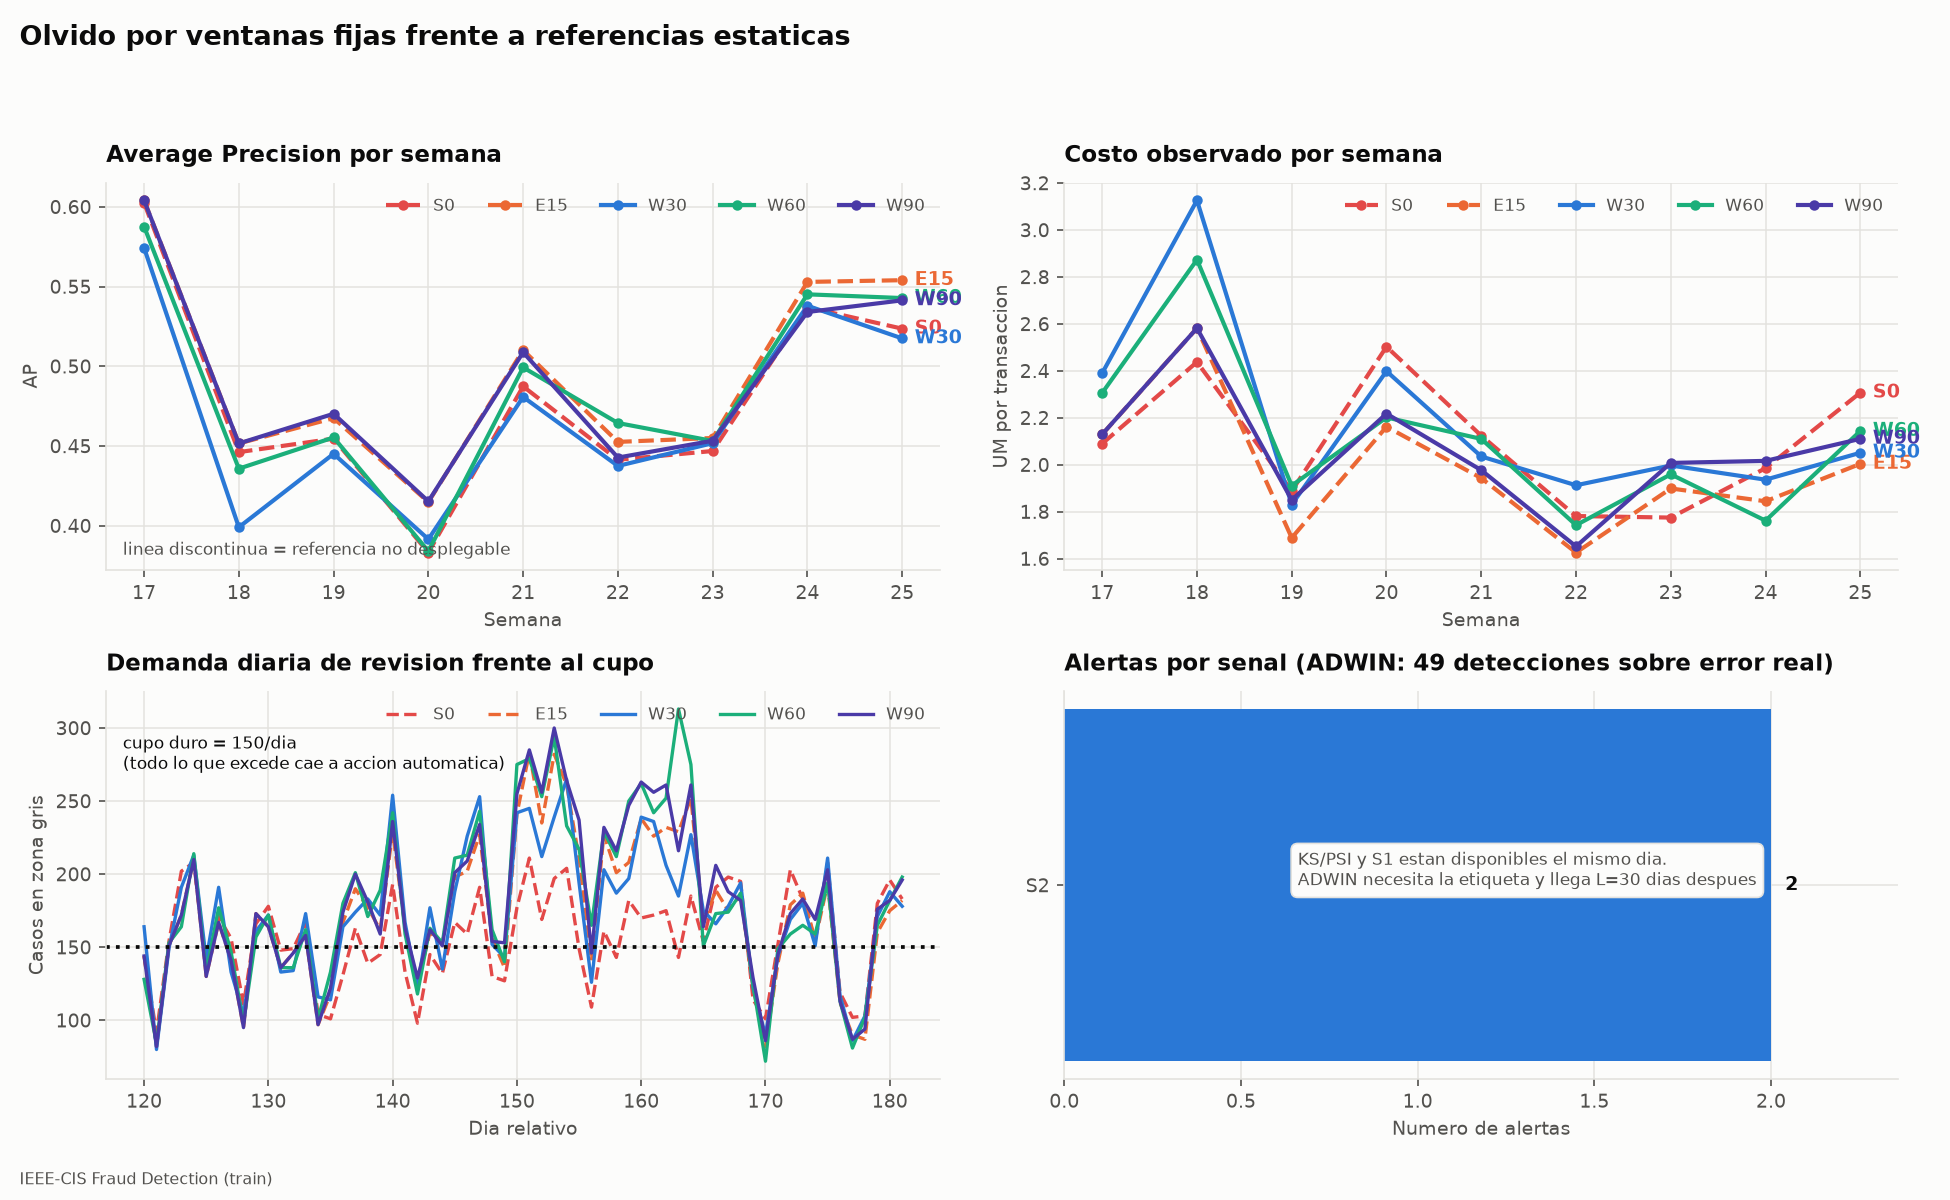

In [12]:
from IPython.display import Image, display
display(Image(filename=str(REPORTS / "figures" / "drift_adaptacion.png")))

## 7. Costo de cómputo

In [13]:
display(pd.read_csv(REPORTS / "tables" / "costos_computo.csv").round(2))

presupuesto = read_json(RUN_DIR / "budget.json")
print(f"\nConsumido: {presupuesto['consumed_minutes']:.1f} min de "
      f"{presupuesto['total_minutes']:.0f}  ({presupuesto['remaining_minutes']:.1f} restantes)")

,kind,n_tareas,segundos,minutos,porcentaje_presupuesto
0,fit_tuning,18,1139.50,18.99,3.96
1,fit_final,9,904.05,15.07,3.14
2,backtest,1,294.27,4.90,1.02
3,fit_seleccion_W,3,25.50,0.43,0.09
4,politica,3,5.38,0.09,0.02



Consumido: 39.5 min de 480  (440.5 restantes)


## 8. Alcance

- Es un backtest retrospectivo, y la selección previa del dataset ya examinó
  periodos tardíos.
- Los costos son simulados bajo supuestos declarados.
- Cada estrategia se entrena con una sola semilla; las 18 combinaciones de robustez
  varían el remuestreo y no el entrenamiento.
- W60 se eligió en desarrollo. Que otra ventana rinda mejor en test es un
  diagnóstico retrospectivo y no justifica reajustar.